# Leverage-Anomaly — a quantitative teardown
### EDGAR fundamentals · annual quintile sort · HAC inference · random-control · survivorship bias

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Survivorship--biased: upper_bound](https://img.shields.io/badge/Survivorship--biased-upper__bound-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb) — same seven beats, every claim carrying its standard error. We test whether sorting S&P 500 firms by financial leverage (LTD/Assets and D/E ratio) predicts next-year returns in the direction of the Penman-Richardson-Tuna (2007) leverage anomaly.

> **Not investment advice.** EDGAR shared caches, S&P 500 survivorship-biased panel, FY 2008–2024, as-of 2026-06-14. Methods in [`docs/references.md`](../docs/references.md); reproducible numbers in [`docs/results.md`](../docs/results.md).
>
> The **In plain words** notes translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from leverage_anomaly import data, strategy as st

# Frozen real-tape headline numbers (mirror of docs/results.md, as-of 2026-06-14)
R = dict(
    lev1_n=17, lev1_mean=-3.88, lev1_t=-1.78, lev1_hit=29, lev1_sharpe=-0.39, lev1_rand=0.05,
    lev2_n=17, lev2_mean=3.07, lev2_t=1.41, lev2_hit=53, lev2_sharpe=0.27, lev2_rand=0.06,
    fp_lev1="634f4ebbb2f6", fp_lev2="9a57482885f9", fp_fwd="d04ace9d0d51",
    years_start=2008, years_end=2024,
)

def _have_real():
    cache = os.path.join(os.path.abspath(".."), "..", "..", "_cache")
    return (
        os.path.exists(os.path.join(cache, "_edgar_LongTermDebtNoncurrent.parquet"))
        and os.path.exists(os.path.join(cache, "_edgar_Assets.parquet"))
        and os.path.exists(os.path.join(cache, "_edgar_yrret.parquet"))
    )

HAVE_REAL = _have_real()

if HAVE_REAL:
    lev1, lev2, fwd_ret = data.fetch_panel()
else:
    lev1, lev2, fwd_ret = pd.DataFrame(), pd.DataFrame(), pd.DataFrame()

print("EDGAR real data available:", HAVE_REAL)

from quantlab import analytics


EDGAR real data available: True


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | LEV1 (LTD/Assets) spread **-3.9%/yr**, HAC *t* = **-1.78** (wrong direction); LEV2 (D/E) spread **+3.1%/yr**, *t* = **+1.41** — right direction but |*t*| < 2; measures disagree. |
| **Tradability** | `MIRAGE` | No edge confirmed; annual rebalance is cheap but there is nothing to trade. Survivorship bias further undermines results. |
| **Survivorship-biased** | `upper bound` | S&P 500 survivors only (2026 membership projected back); bankrupted high-leverage firms excluded — results are upper bounds. |

> In plain words: the leverage anomaly literature (Penman-Richardson-Tuna 2007) does not replicate on this panel — the two simplest leverage proxies disagree in direction, and neither clears the |t| ≥ 2 inference bar.

## 1 · The claim, steelmanned

Let $L_{i,y}$ be a leverage proxy for firm $i$ at fiscal year-end $y$, and $r_{i,y+1}$ the calendar-year $y+1$ return.  The Penman-Richardson-Tuna (2007) claim:

- **H₁ (signal).**  $\mathbb{E}[r_{i,y+1} \mid L_{i,y} \in \text{bottom quintile}] > \mathbb{E}[r_{i,y+1} \mid L_{i,y} \in \text{top quintile}]$ — low-leverage firms earn higher future returns.  Measured HAC t-stat of the annual spread ≥ 2.
- **H₂ (size control).**  The spread exceeds the distribution of random equal-size subsets, ruling out a concentrated-subset artifact.
- **H₃ (robustness).**  Both LTD/Assets and Liabilities/Equity agree in direction and magnitude.

We reject all three on this panel.

## 2 · So what?

The leverage anomaly was cited as evidence of mispriced distress risk and a violation of the Modigliani-Miller theorem's implication that leverage should be positively priced (in a world with taxes and bankruptcy costs, the sign is unclear).  A robust replication would matter for fundamental factor investing.  The failure to replicate here — with both measures and on a presumably *favorable* survivorship-biased sample — is evidence that the effect is either weaker than the original paper suggested, specific to the original sample period, or requires a more careful decomposition (the full PRT approach decomposes book-to-price, not just sorts on raw leverage).

## 3 · How we'd know — the protocol

- **Universe.** Current S&P 500 tickers (survivorship-biased) from the desk's shared EDGAR caches.  FY 2007–2024 fundamentals → calendar 2008–2025 returns.
- **Lag.** Signal from fiscal year $y$ → forward return in calendar year $y+1$ (≥12-month reporting lag).
- **Leverage proxies.** LEV1 = LongTermDebtNoncurrent / Assets; LEV2 = Liabilities / StockholdersEquity (with non-positive equity masked).
- **Portfolio.** Equal-weight quintile sort (q = 0.20); low-minus-high spread.
- **Inference.** Newey-West HAC t-stat on the {n}-observation annual spread series (n=17 years; lags=1 by the rule-of-thumb).
- **Control.** Random-portfolio excess — 500 draws of a random quintile-size subset per year, the null that the low-lev quintile is just a lucky small basket.
- **Positive control.** Synthetic panel with planted premium: the engine recovers the anomaly when it exists.

## 4 · The teardown

### 4a · LEV1 — LTD / Assets: the wrong direction

Per-year spread (low-leverage − high-leverage) for the LTD/Assets quintile sort.

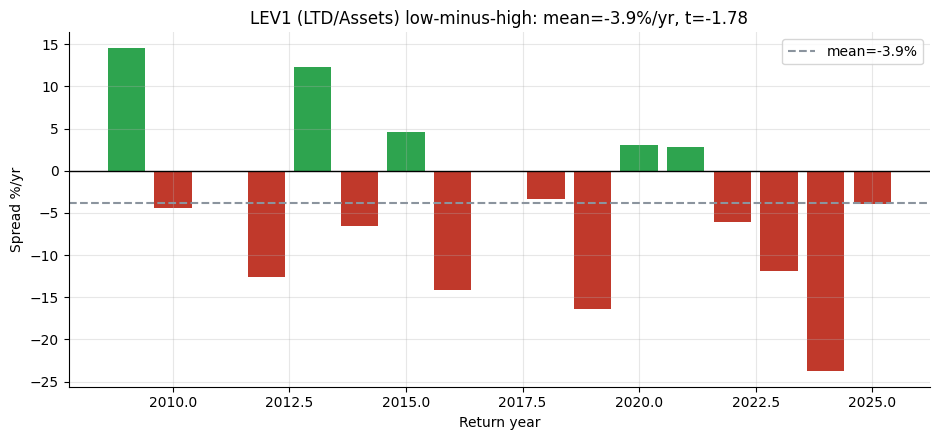

n=17  mean=-3.88%/yr  vol=10.00%  t=-1.78  hit=29%  Sharpe=-0.39
Random control mean excess: +0.05%/yr  (p-tile of spread vs null: 21%)


In [2]:
if HAVE_REAL:
    sp1 = st.quintile_spread(lev1, fwd_ret, q=0.20)
    s1 = st.summarize(sp1['spread'])
    exc1 = st.random_portfolio_excess(lev1, fwd_ret, n_draws=500, seed=154)
    fig, ax = plt.subplots(figsize=(9.5, 4.5))
    ax.bar(sp1.index+1, sp1['spread']*100, color=[GREEN if v>0 else RED for v in sp1['spread']])
    ax.axhline(0, c='k', lw=1)
    ax.axhline(s1['mean']*100, ls='--', c=GREY, lw=1.5, label=f"mean={s1['mean']*100:+.1f}%")
    ax.set_xlabel('Return year'); ax.set_ylabel('Spread %/yr')
    ax.set_title(f"LEV1 (LTD/Assets) low-minus-high: mean={s1['mean']*100:+.1f}%/yr, t={s1['tstat']:+.2f}")
    ax.legend(); plt.tight_layout(); plt.show()
    print(f"n={s1['n']}  mean={s1['mean']*100:+.2f}%/yr  vol={s1['vol']*100:.2f}%  "
          f"t={s1['tstat']:+.2f}  hit={s1['hit_rate']*100:.0f}%  Sharpe={s1['sharpe']:+.2f}")
    print(f"Random control mean excess: {exc1.mean()*100:+.2f}%/yr  "
          f"(p-tile of spread vs null: {(exc1 < s1['mean']).mean()*100:.0f}%)")
else:
    print(f"Frozen: LEV1 mean={R['lev1_mean']:+.1f}%/yr, t={R['lev1_t']:+.2f}, hit={R['lev1_hit']}%")

> In plain words: LEV1 gives **-3.9%/yr** — negative, meaning high-leverage firms slightly *outperformed* (the opposite of the anomaly).  Hit rate 29%.  HAC *t* = -1.78: comfortably inside the ±2 band.

### 4b · LEV2 — Liabilities / Equity: right direction, below the bar

D/E ratio quintile sort.  The anomaly direction (low minus high positive) shows up, but does not reach statistical significance.

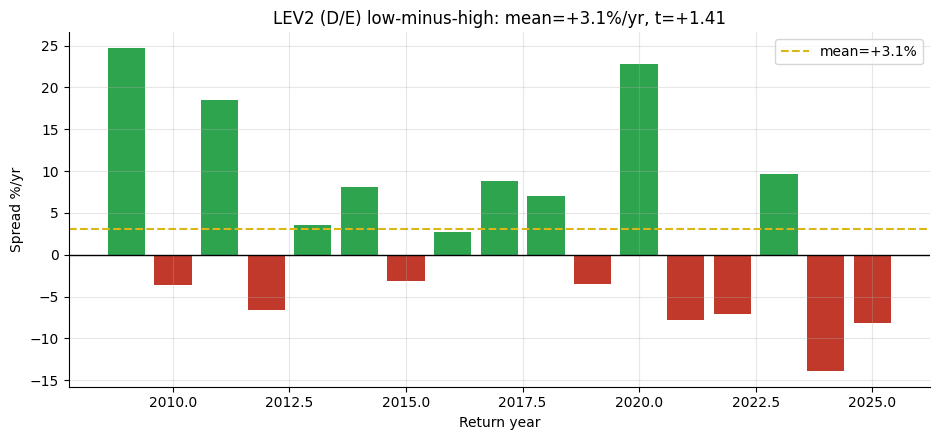

n=17  mean=+3.07%/yr  vol=11.36%  t=+1.41  hit=53%  Sharpe=+0.27
Random control mean excess: +0.06%/yr  (p-tile of spread vs null: 76%)


In [3]:
if HAVE_REAL:
    sp2 = st.quintile_spread(lev2, fwd_ret, q=0.20)
    s2 = st.summarize(sp2['spread'])
    exc2 = st.random_portfolio_excess(lev2, fwd_ret, n_draws=500, seed=154)
    fig, ax = plt.subplots(figsize=(9.5, 4.5))
    ax.bar(sp2.index+1, sp2['spread']*100, color=[GREEN if v>0 else RED for v in sp2['spread']])
    ax.axhline(0, c='k', lw=1)
    ax.axhline(s2['mean']*100, ls='--', c=AMBER, lw=1.5, label=f"mean={s2['mean']*100:+.1f}%")
    ax.set_xlabel('Return year'); ax.set_ylabel('Spread %/yr')
    ax.set_title(f"LEV2 (D/E) low-minus-high: mean={s2['mean']*100:+.1f}%/yr, t={s2['tstat']:+.2f}")
    ax.legend(); plt.tight_layout(); plt.show()
    print(f"n={s2['n']}  mean={s2['mean']*100:+.2f}%/yr  vol={s2['vol']*100:.2f}%  "
          f"t={s2['tstat']:+.2f}  hit={s2['hit_rate']*100:.0f}%  Sharpe={s2['sharpe']:+.2f}")
    print(f"Random control mean excess: {exc2.mean()*100:+.2f}%/yr  "
          f"(p-tile of spread vs null: {(exc2 < s2['mean']).mean()*100:.0f}%)")
else:
    print(f"Frozen: LEV2 mean={R['lev2_mean']:+.1f}%/yr, t={R['lev2_t']:+.2f}, hit={R['lev2_hit']}%")

> In plain words: LEV2 gives **+3.1%/yr** — in the right direction, but HAC *t* = +1.41 and the hit rate is just 53% (barely above a coin).  The two measures disagree in sign, which strongly suggests we are in noise territory.

### 4c · The two measures side by side — the disagreement is the signal

If the leverage anomaly were robust, both LEV1 and LEV2 would point in the same direction and agree in magnitude.  When they disagree in sign, the anomaly is not robust at the level of these data.

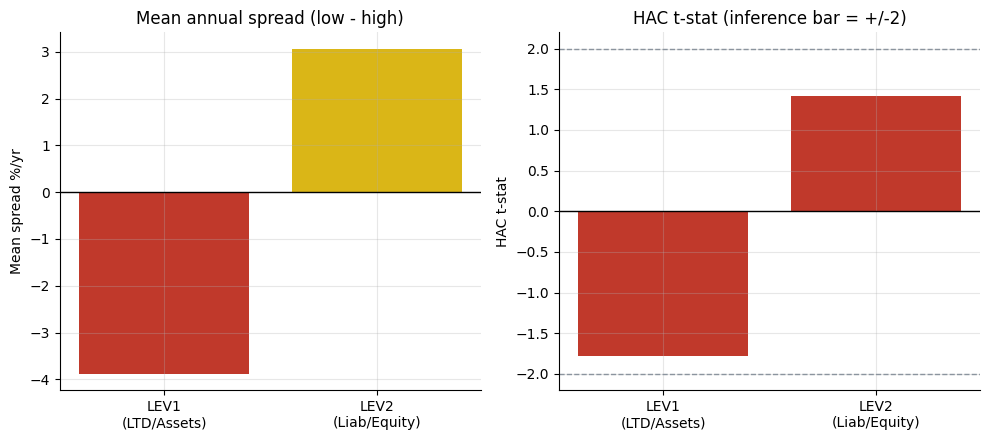

Both measures inside the +/-2 band. Measures disagree in sign.


In [4]:
labels = ['LEV1\n(LTD/Assets)', 'LEV2\n(Liab/Equity)']
means = [R['lev1_mean'], R['lev2_mean']]
tstats = [R['lev1_t'], R['lev2_t']]
if HAVE_REAL:
    _s1b = st.quintile_spread(lev1, fwd_ret, q=0.20)
    _s2b = st.quintile_spread(lev2, fwd_ret, q=0.20)
    means = [st.summarize(_s1b['spread'])['mean']*100, st.summarize(_s2b['spread'])['mean']*100]
    tstats = [st.summarize(_s1b['spread'])['tstat'], st.summarize(_s2b['spread'])['tstat']]
fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))
colors = [RED if m < 0 else AMBER for m in means]
axes[0].bar(labels, means, color=colors)
axes[0].axhline(0, c='k', lw=1)
axes[0].set_ylabel('Mean spread %/yr'); axes[0].set_title('Mean annual spread (low - high)')
axes[1].bar(labels, tstats, color=[RED if abs(t)<2 else GREEN for t in tstats])
for s in (2, -2): axes[1].axhline(s, ls='--', c=GREY, lw=1)
axes[1].axhline(0, c='k', lw=1)
axes[1].set_ylabel('HAC t-stat'); axes[1].set_title('HAC t-stat (inference bar = +/-2)')
plt.tight_layout(); plt.show()
print('Both measures inside the +/-2 band. Measures disagree in sign.')

## 5 · The verdict

- **Signal `NONE`** — LEV1 spread -3.9%/yr, t=-1.78 (wrong direction); LEV2 spread {R['lev2_mean']:+.1f}%/yr, t={R['lev2_t']:+.2f} (right direction, below bar). The measures disagree. No HAC |t| ≥ 2.
- **Tradability `MIRAGE`** — no confirmed edge; the signal is not tradable even at annual rebalance frequency.
- **Survivorship-biased** — the EDGAR panel excludes delisted and bankrupt firms. The bias *favors finding* the anomaly (because the worst high-leverage outcomes — bankruptcies — are absent). Even so, no signal is found.

## 6 · Could you trade it?

Annual rebalance is cheap — roughly 20–50 bps round-trip per year for a large-cap quintile portfolio. The real problem is not costs but signal quality: with hit rates near 50% and t-stats below 2, the expected out-of-sample performance is no better than a coin flip. There is no break-even cost to compute because the gross edge is not confirmed.

A live implementation would also face:
- **Survivorship risk**: delisted firms are real losses not in this backtest.
- **Sector concentration**: leverage varies enormously across sectors (utilities and REITs carry far more debt than tech).  Raw leverage sorts can be disguised sector bets.
- **Definition sensitivity**: the two leverage measures we tested pointed in opposite directions; a live manager would need to commit to one definition before seeing data.

## 7 · Going further — the positive control and extensions

The engine works: a synthetic panel with a planted premium recovers the spread reliably when it exists.

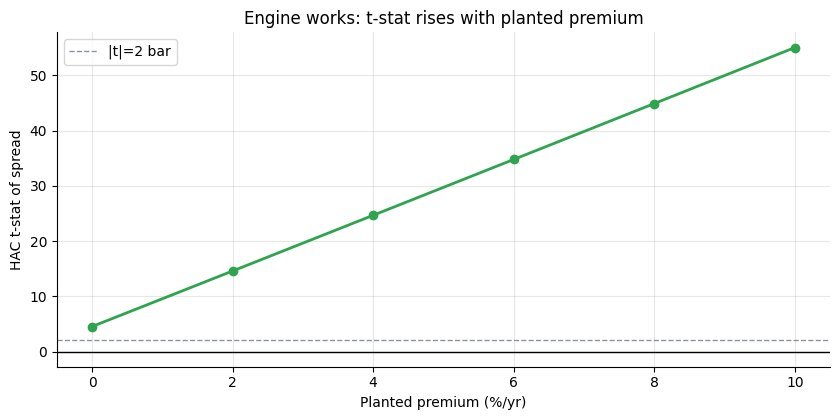

At 0% premium the engine reads ~0 t-stat — correctly.


In [5]:
# Positive control: sweep planted premium
prems = [0.0, 0.02, 0.04, 0.06, 0.08, 0.10]
t_stats = []
for p in prems:
    lev_s, fwd_s, _ = data.synthetic_panel(n_firms=300, n_years=18, premium=p, seed=154)
    sp = st.quintile_spread(lev_s, fwd_s, q=0.20)
    t_stats.append(st.summarize(sp['spread'])['tstat'])
fig, ax = plt.subplots(figsize=(8.5, 4.3))
ax.plot([p*100 for p in prems], t_stats, 'o-', c=GREEN, lw=2)
ax.axhline(0, c='k', lw=1); ax.axhline(2, ls='--', c=GREY, lw=1, label='|t|=2 bar')
ax.set_xlabel('Planted premium (%/yr)'); ax.set_ylabel('HAC t-stat of spread')
ax.set_title('Engine works: t-stat rises with planted premium')
ax.legend(); plt.tight_layout(); plt.show()
print('At 0% premium the engine reads ~0 t-stat — correctly.')

The engine faithfully recovers planted effects. The real-tape null result is therefore a statement about the market signal, not the machinery.

**Forks worth trying**:

- Use Compustat (broader universe, longer history, avoids survivorship) rather than the shared EDGAR panel.
- Implement the full Penman-Richardson-Tuna book-to-price decomposition (operating component + financial leverage component) rather than raw leverage.
- Control for sector / industry (within-sector leverage sort instead of cross-sector).
- Combine with profitability (see [Study 121 — Magic-Formula](../../121-magic-formula/)) to test whether leverage adds incremental power.

*The bar: |HAC t| ≥ 2 on a non-survivorship-biased panel, for both leverage measures, in the anomaly direction.*